In [2]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder
from cleanlab.filter import find_label_issues

penguins = pd.read_csv('../program/penguins.csv')
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
penguins.describe(include="all")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


In [4]:
species_dist = penguins['species'].value_counts()
island_dist = penguins['island'].value_counts()
sex_dist = penguins['sex'].value_counts()

print(species_dist, end="\n\n")
print(island_dist, end="\n\n")
print(sex_dist, end="\n\n")

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64



In [5]:
#  `species`: There are 3 species of penguins in the dataset: Adelie (`152`), Gentoo (`124`), and Chinstrap (`68`).
#  `island`: Penguins are from 3 islands: Biscoe (`168`), Dream (`124`), and Torgersen (`52`).
#  `sex`: We have `168` male penguins, `165` female penguins, and `1` penguin with an ambiguous gender (`.`).

In [6]:
penguins.groupby(['sex'])['species'].count().reset_index()

,sex,species
0,.,1
1,FEMALE,165
2,MALE,168


In [7]:
# By a slight margin, most of the pengiuns are of gender Male apart from a single one which is of male dot

In [8]:
# There are missing values in
penguins.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [9]:
# Impute missing values of every column with the most frequent value
imputer = SimpleImputer(strategy="most_frequent")
penguins.iloc[:, :] = imputer.fit_transform(penguins)
penguins.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

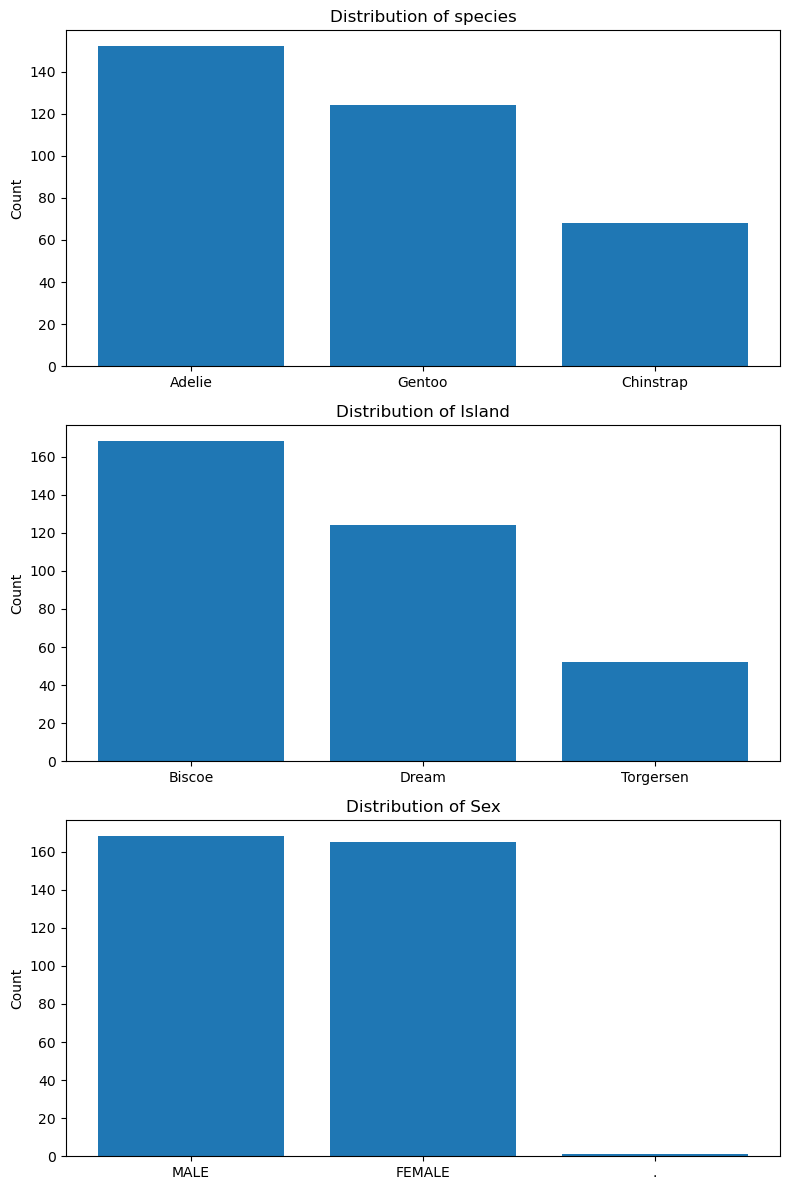

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(8, 12))

ax[0].bar(species_dist.index, species_dist.values)
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of species')

ax[1].bar(island_dist.index, island_dist.values)
ax[1].set_ylabel('Count')
ax[1].set_title('Distribution of Island')

ax[2].bar(sex_dist.index, sex_dist.values)
ax[2].set_ylabel('Count')
ax[2].set_title('Distribution of Sex')

plt.tight_layout()

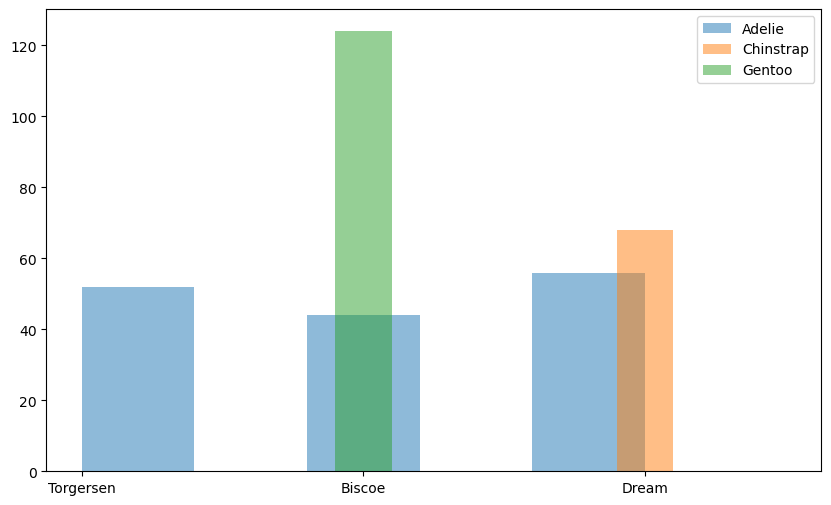

In [11]:
unique_species = penguins["species"].unique()

fig, ax = plt.subplots(figsize=(10,6))
for species in unique_species:
    data = penguins[penguins["species"] == species]
    ax.hist(data["island"], bins = 5, alpha=0.5, label=species)

ax.legend()
plt.show()

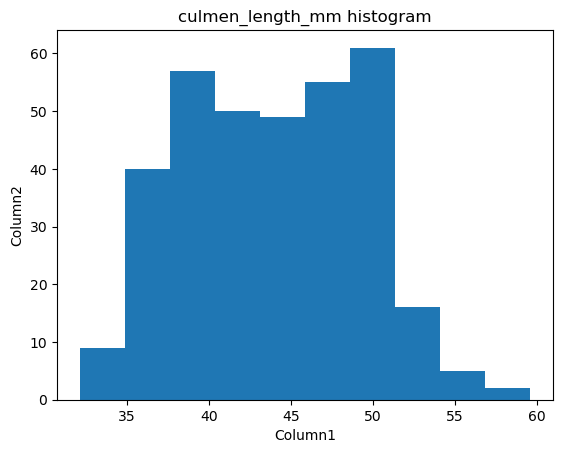

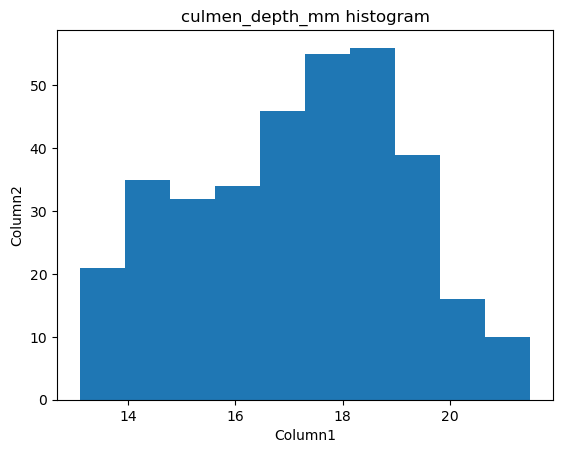

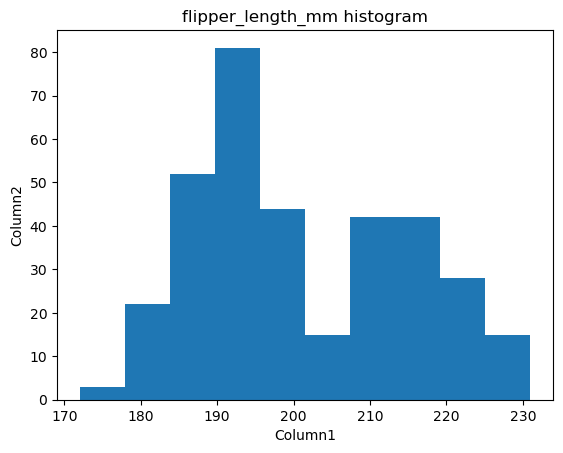

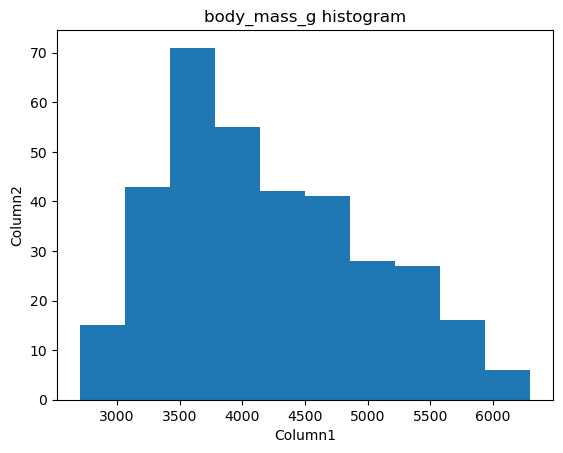

In [41]:
# Outlier detection
num_cols = penguins.select_dtypes(include='number')

for  column in num_cols:
    plt.hist(num_cols[column])
    plt.title(f'{column} histogram')
    plt.xlabel('Column1')
    plt.ylabel('Column2')
    plt.show()

In [46]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.1)  # contamination is an estimate of the outlier proportion

# Fit and predict outliers; -1 indicates an outlier, 1 indicates a normal point
num_cols['outlier'] = iso_forest.fit_predict(num_cols[['culmen_length_mm']])

# Display the outliers
outliers = num_cols[num_cols['outlier'] == -1]
print("Outliers detected by Isolation Forest:\n", outliers)

Outliers detected by Isolation Forest:
      culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
8                34.1             18.1              193.0       3475.0   
14               34.6             21.1              198.0       4400.0   
18               34.4             18.4              184.0       3325.0   
25               35.3             18.9              187.0       3800.0   
52               35.0             17.9              190.0       3450.0   
54               34.5             18.1              187.0       2900.0   
66               35.5             16.2              195.0       3350.0   
70               33.5             19.0              190.0       3600.0   
74               35.5             17.5              190.0       3700.0   
80               34.6             17.2              189.0       3200.0   
83               35.1             19.4              193.0       4200.0   
92               34.0             17.1              185.0       3400.0  

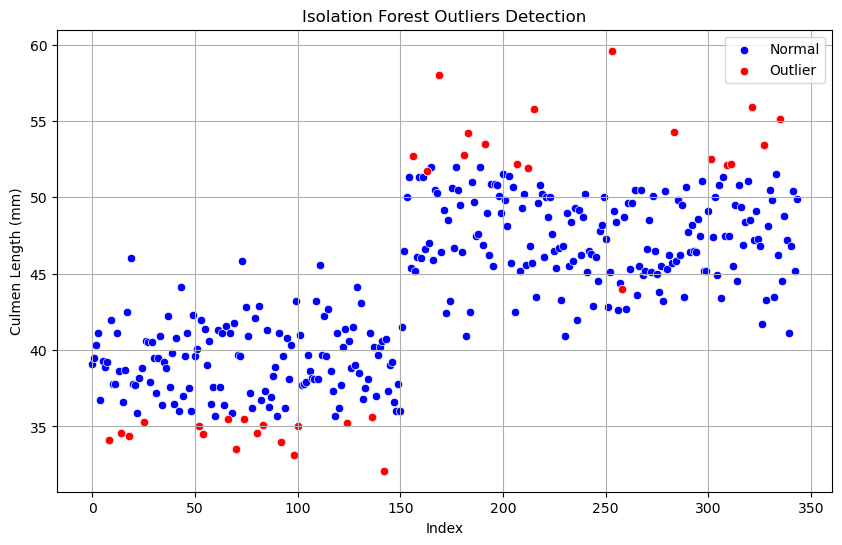

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=num_cols.index, y='culmen_length_mm', data=num_cols, label='Normal', color='blue')

# Now, plot the outliers in a different color
sns.scatterplot(x=outliers.index, y='culmen_length_mm', data=outliers, label='Outlier', color='red')

plt.title('Isolation Forest Outliers Detection')
plt.xlabel('Index')
plt.ylabel('Culmen Length (mm)')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Assuming 'data' is your DataFrame, 'categorical_feature' is your categorical column, and 'target' is your target column
contingency_table = pd.crosstab(penguins['sex'], penguins['species'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared:", chi2)
print("p-value:", p)

if p < 0.05:
    print("There is a significant association between the feature and the target.")
else:
    print("No significant association was found.")

Chi-squared: 1.9221318890821573
p-value: 0.7500782310120552
No significant association was found.


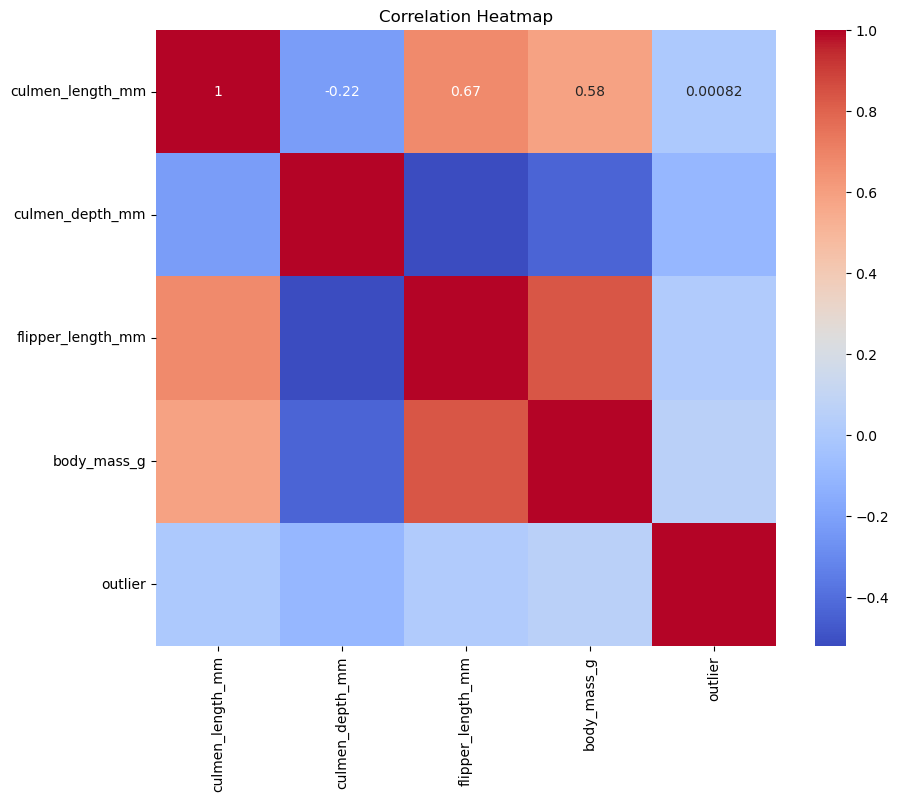

In [65]:
one_hot_encoded = pd.get_dummies(penguins['sex'], prefix='category')
data = pd.concat([penguins, one_hot_encoded], axis=1)
correlation_matrix = num_cols.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

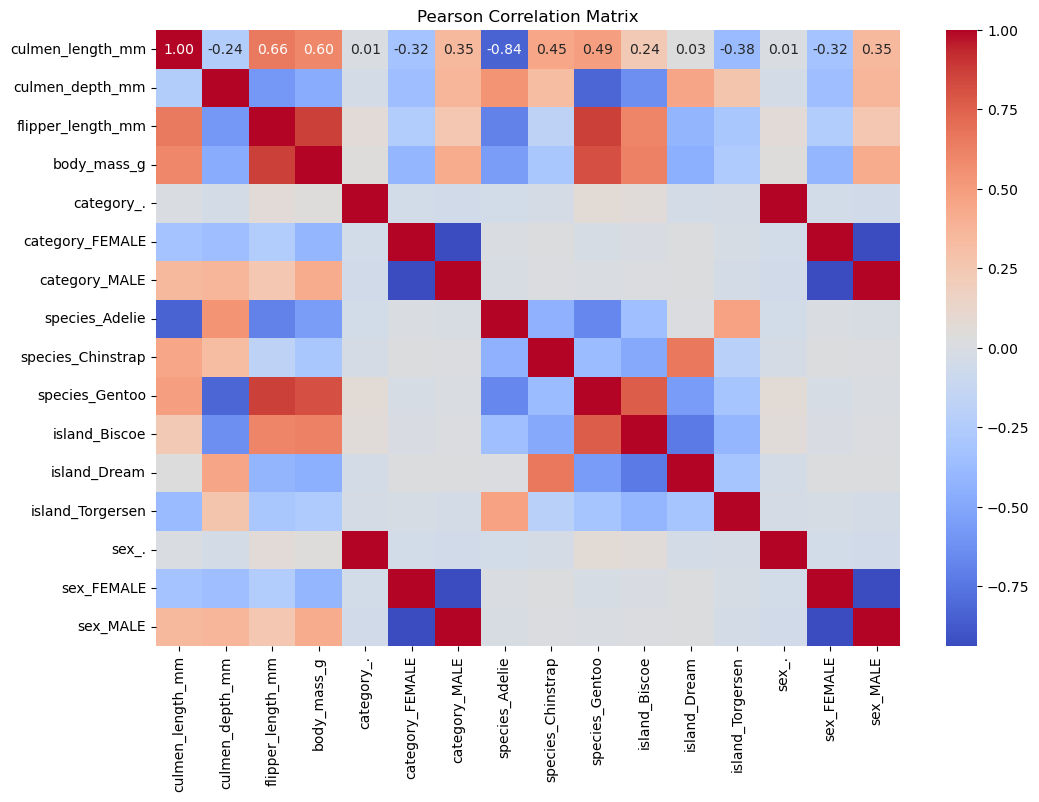

In [71]:
categorical_cols = data.select_dtypes(include=['object']).columns
# One-Hot Encode categorical data
one_hot_encoded_data = pd.get_dummies(data, columns=categorical_cols)

# Calculate the Pearson correlation matrix
corr_matrix = one_hot_encoded_data.corr()

# Plotting the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

Accuracy: 0.9855072463768116


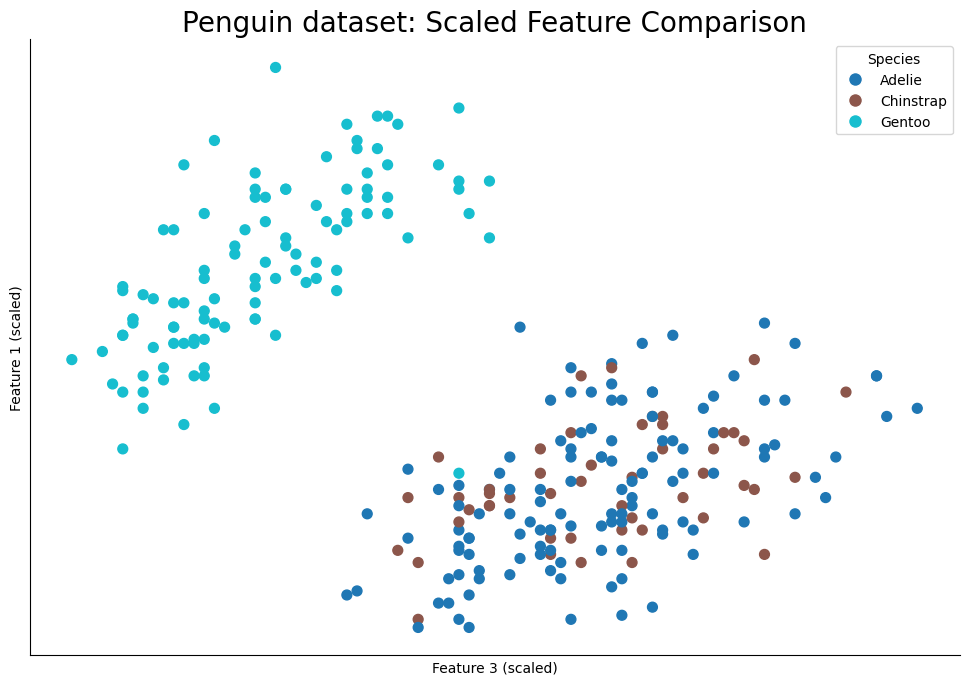

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from cleanlab.classification import CleanLearning
import matplotlib.pyplot as plt

# Seed for reproducibility
seed = 2
np.random.seed(seed=seed)

# Assuming 'penguins' is previously loaded DataFrame with the necessary data
X = penguins.drop('species', axis=1)
X = pd.get_dummies(X, columns=X.select_dtypes(include=['object']).columns)
y = penguins['species']

# Create a mapping from species names to integers
species_mapping = {species: idx for idx, species in enumerate(y.unique())}
y_mapped = y.map(species_mapping)

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=seed)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Machine learning model setup with CleanLearning
clf = LogisticRegression(solver="lbfgs", multi_class="auto", max_iter=1000)
cl = CleanLearning(clf=clf, seed=seed, verbose=False)

# Train and evaluate model using CleanLearning
cl.fit(X_train_scaled, y_train)
predictions = cl.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

# Plotting
try:
    plt.figure(figsize=(12, 8))
    color_list = plt.cm.tab10(np.linspace(0, 1, len(species_mapping)))
    scatter = plt.scatter(X_train_scaled[:, 1], X_train_scaled[:, 3], c=[color_list[i] for i in y_train], s=50)

    # Create a legend
    legend_labels = {v: k for k, v in species_mapping.items()}  # Reverse the mapping for labeling
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[i],
                          markerfacecolor=color_list[i], markersize=10) for i in range(len(species_mapping))]
    plt.legend(handles=handles, title="Species")
    
    plt.title("Penguin dataset: Scaled Feature Comparison", fontsize=20)
    plt.xlabel("Feature 3 (scaled)")  # Update according to actual feature names if known
    plt.ylabel("Feature 1 (scaled)")
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().get_xaxis().set_ticks([])
    plt.gca().get_yaxis().set_ticks([])
    plt.show()
except Exception as e:
    print("Plotting error:", e)

In [16]:
# Fit the model on the entire training dataset
clf.fit(X_train_scaled, y_train)

# Predict on the same training set
train_predictions = clf.predict(X_train_scaled)

# Find discrepancies between the predictions and actual labels
mislabeled_indices = np.where(train_predictions != y_train)[0]
print("Indices of potential mislabels in the training set:", mislabeled_indices)

# Optionally, examine the suspect data points more closely
suspect_data = X_train.iloc[mislabeled_indices]
suspect_labels = y_train.iloc[mislabeled_indices]
print("Suspect data points:")
print(suspect_data)
print("Suspect labels:")
print(suspect_labels)

Indices of potential mislabels in the training set: [104]
Suspect data points:
     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
339              41.1             17.0              190.0       3800.0   

     island_Biscoe  island_Dream  island_Torgersen  sex_.  sex_FEMALE  \
339           True         False             False  False       False   

     sex_MALE  
339      True  
Suspect labels:
339    2
Name: species, dtype: int64


Row 339 (in the one-hot encoded dataset) shows that Gentoo might not be the correct species for this instance. Need to check!